In [1058]:
import pandas as pd
import numpy as np
import missingno as msno
from scipy.stats import norm
from matplotlib import pyplot as plt

# Data ingestion, cleaning and merging

In [1059]:
dataset_food_inflation_rate = pd.read_csv('./data/food_inflation_rate.csv')

In [1060]:
dataset_food_inflation_rate.head()

,Domain Code,Domain,Area Code (M49),Area,Year Code,Year,Item Code,Item,Months Code,Months,Element Code,Element,Unit,Value,Flag,Flag Description,Note
0,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7001,January,6121,Value,%,2.607987,E,Estimated value,NaN
1,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7002,February,6121,Value,%,3.896104,E,Estimated value,NaN
2,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7003,March,6121,Value,%,2.967121,E,Estimated value,NaN
3,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7004,April,6121,Value,%,2.149682,E,Estimated value,NaN
4,CP,Consumer Price Indices,248,Åland Islands,2012,2012,23014,Food price inflation,7005,May,6121,Value,%,3.559871,E,Estimated value,NaN


In [1061]:
dataset_food_inflation_rate = dataset_food_inflation_rate[['Area', 'Year', 'Months', 'Value']]

In [1062]:
dataset_food_inflation_rate = dataset_food_inflation_rate.rename(columns = {'Value': 'Food Inflation Rate'})

In [1063]:
dataset_food_inflation_rate.head()

,Area,Year,Months,Food Inflation Rate
0,Åland Islands,2012,January,2.607987
1,Åland Islands,2012,February,3.896104
2,Åland Islands,2012,March,2.967121
3,Åland Islands,2012,April,2.149682
4,Åland Islands,2012,May,3.559871


In [1064]:
dataset_food_inflation_rate = dataset_food_inflation_rate.groupby(['Area', 'Year'], as_index=False)['Food Inflation Rate'].mean()

In [1065]:
dataset_food_inflation_rate.head()

,Area,Year,Food Inflation Rate
0,Albania,2012,2.404087
1,Albania,2013,4.214607
2,Albania,2014,2.212385
3,Albania,2015,4.294233
4,Albania,2016,3.254620


In [1066]:
dataset_food_inflation_rate.isnull().sum()

Area                   0
Year                   0
Food Inflation Rate    0
dtype: int64

In [1067]:
dataset_raw_gdp = pd.read_csv('./data/raw_gdp.csv')

In [1068]:
dataset_raw_gdp.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2012,2012,million USD,12319.779604,X,Figure from international organizations,NaN
1,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2013,2013,million USD,12776.280738,X,Figure from international organizations,NaN
2,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2014,2014,million USD,13228.240079,X,Figure from international organizations,NaN
3,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2015,2015,million USD,11386.924853,X,Figure from international organizations,NaN
4,MK,Macro Indicators,8,Albania,6110,Value US$,22008,Gross Domestic Product,2016,2016,million USD,11861.356451,X,Figure from international organizations,NaN


In [1069]:
dataset_raw_gdp = dataset_raw_gdp[['Area', 'Year', 'Value']]

In [1070]:
dataset_raw_gdp = dataset_raw_gdp.rename(columns = {'Value': 'Raw GDP'})

In [1071]:
dataset_raw_gdp.head()

,Area,Year,Raw GDP
0,Albania,2012,12319.779604
1,Albania,2013,12776.280738
2,Albania,2014,13228.240079
3,Albania,2015,11386.924853
4,Albania,2016,11861.356451


In [1072]:
dataset_raw_gdp.isnull().sum()

Area       0
Year       0
Raw GDP    0
dtype: int64

In [1073]:
dataset_gdp_growth_rate = pd.read_csv('./data/gdp_growth_rate.csv')

In [1074]:
dataset_gdp_growth_rate.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2012,2012,%,-4.430218,X,Figure from international organizations,NaN
1,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2013,2013,%,3.705432,X,Figure from international organizations,NaN
2,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2014,2014,%,3.537487,X,Figure from international organizations,NaN
3,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2015,2015,%,-13.919579,X,Figure from international organizations,NaN
4,MK,Macro Indicators,8,Albania,6129,Annual growth US$,22008,Gross Domestic Product,2016,2016,%,4.166459,X,Figure from international organizations,NaN


In [1075]:
dataset_gdp_growth_rate.isnull().sum()

Domain Code           0
Domain                0
Area Code (M49)       0
Area                  0
Element Code          0
Element               0
Item Code             0
Item                  0
Year Code             0
Year                  0
Unit                  0
Value                 0
Flag                  0
Flag Description      0
Note                515
dtype: int64

In [1076]:
dataset_gdp_growth_rate = dataset_gdp_growth_rate[['Area', 'Year', 'Value']]

In [1077]:
dataset_gdp_growth_rate = dataset_gdp_growth_rate.rename(columns = {"Value": "GDP Growth Rate"})

In [1078]:
dataset_gdp_growth_rate.head()

,Area,Year,GDP Growth Rate
0,Albania,2012,-4.430218
1,Albania,2013,3.705432
2,Albania,2014,3.537487
3,Albania,2015,-13.919579
4,Albania,2016,4.166459


In [1079]:
dataset_gdp_growth_rate.isnull().sum()

Area               0
Year               0
GDP Growth Rate    0
dtype: int64

In [1080]:
dataset_producer_prices = pd.read_csv('./data/producer_prices.csv')

In [1081]:
dataset_producer_prices[dataset_producer_prices['Area'] == "Switzerland"]

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
18667,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),01341,Apples,2012,2012,7021,Annual value,USD,1079.3,A,Official figure
18668,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),01341,Apples,2013,2013,7021,Annual value,USD,1097.2,A,Official figure
18669,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),01341,Apples,2014,2014,7021,Annual value,USD,1095.9,A,Official figure
18670,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),01341,Apples,2015,2015,7021,Annual value,USD,1046.4,A,Official figure
18671,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),01341,Apples,2016,2016,7021,Annual value,USD,988.4,A,Official figure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19499,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),0111,Wheat,2019,2019,7021,Annual value,USD,464.9,A,Official figure
19500,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),0111,Wheat,2020,2020,7021,Annual value,USD,500.6,A,Official figure
19501,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),0111,Wheat,2021,2021,7021,Annual value,USD,555.9,A,Official figure
19502,PP,Producer Prices,756,Switzerland,5532,Producer Price (USD/tonne),0111,Wheat,2022,2022,7021,Annual value,USD,579.2,A,Official figure


In [1082]:
dataset_producer_prices = dataset_producer_prices[['Area', 'Year', 'Item', 'Value']]

In [1083]:
dataset_producer_prices = dataset_producer_prices.rename(columns={"Value": "Item Price Per Tonne"})

In [1084]:
dataset_producer_prices.head()

,Area,Year,Item,Item Price Per Tonne
0,Albania,2012,Apples,369.7
1,Albania,2013,Apples,492.1
2,Albania,2014,Apples,474.8
3,Albania,2015,Apples,389.0
4,Albania,2016,Apples,381.3


In [1085]:
dataset_producer_prices.isnull().sum()

Area                    0
Year                    0
Item                    0
Item Price Per Tonne    0
dtype: int64

In [1086]:
dataset_overall_inflation = pd.read_excel('./data/overall_inflation.xlsx')

In [1087]:
dataset_overall_inflation.head()

,Data extracted on 22/07/2024 23:21:37 from [ESTAT],Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,Dataset:,HICP - inflation rate [tec00118],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last updated:,17/07/2024 11:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unit of measure,NaN,Annual average rate of change,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1088]:
dataset_overall_inflation.isnull().sum()

Data extracted on 22/07/2024 23:21:37 from [ESTAT]     3
Unnamed: 1                                             9
Unnamed: 2                                            49
Unnamed: 3                                            13
Unnamed: 4                                            52
Unnamed: 5                                            13
Unnamed: 6                                            52
Unnamed: 7                                            13
Unnamed: 8                                            52
Unnamed: 9                                            13
Unnamed: 10                                           51
Unnamed: 11                                           13
Unnamed: 12                                           49
Unnamed: 13                                           13
Unnamed: 14                                           49
Unnamed: 15                                           13
Unnamed: 16                                           49
Unnamed: 17                    

In [1089]:
columns_to_drop = [f'Unnamed: {i}' for i in range(2, 25) if i % 2 == 0]
columns_to_drop

['Unnamed: 2',
 'Unnamed: 4',
 'Unnamed: 6',
 'Unnamed: 8',
 'Unnamed: 10',
 'Unnamed: 12',
 'Unnamed: 14',
 'Unnamed: 16',
 'Unnamed: 18',
 'Unnamed: 20',
 'Unnamed: 22',
 'Unnamed: 24']

In [1090]:
dataset_overall_inflation = dataset_overall_inflation[12:51]

In [1091]:
dataset_overall_inflation = dataset_overall_inflation.drop(columns=columns_to_drop)

In [1092]:
columns_to_stay = [f'Unnamed: {i}' for i in range(1, 25) if i % 2 == 1]

In [1093]:
dict_rename_columns = {}

In [1094]:
for prev_name, year in zip(columns_to_stay, range(2012, 2024)):
    dict_rename_columns[prev_name] = year

In [1095]:
dict_rename_columns

{'Unnamed: 1': 2012,
 'Unnamed: 3': 2013,
 'Unnamed: 5': 2014,
 'Unnamed: 7': 2015,
 'Unnamed: 9': 2016,
 'Unnamed: 11': 2017,
 'Unnamed: 13': 2018,
 'Unnamed: 15': 2019,
 'Unnamed: 17': 2020,
 'Unnamed: 19': 2021,
 'Unnamed: 21': 2022,
 'Unnamed: 23': 2023}

In [1096]:
dict_rename_columns['Data extracted on 22/07/2024 23:21:37 from [ESTAT]'] = 'Area'

In [1097]:
dataset_overall_inflation = dataset_overall_inflation.rename(columns=dict_rename_columns)

In [1098]:
dataset_overall_inflation

,Area,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
12,Belgium,2.6,1.2,0.5,0.6,1.8,2.2,2.3,1.2,0.4,3.2,10.3,2.3
13,Bulgaria,2.4,0.4,-1.6,-1.1,-1.3,1.2,2.6,2.5,1.2,2.8,13,8.6
14,Czechia,3.5,1.4,0.4,0.3,0.6,2.4,2,2.6,3.3,3.3,14.8,12
15,Denmark,2.4,0.5,0.4,0.2,0,1.1,0.7,0.7,0.3,1.9,8.5,3.4
16,Germany,2.2,1.6,0.8,0.7,0.4,1.7,1.9,1.4,0.4,3.2,8.7,6
17,Estonia,4.2,3.2,0.5,0.1,0.8,3.7,3.4,2.3,-0.6,4.5,19.4,9.1
18,Ireland,1.9,0.5,0.3,0,-0.2,0.3,0.7,0.9,-0.5,2.4,8.1,5.2
19,Greece,1,-0.9,-1.4,-1.1,0,1.1,0.8,0.5,-1.3,0.6,9.3,4.2
20,Spain,2.4,1.5,-0.2,-0.6,-0.3,2,1.7,0.8,-0.3,3,8.3,3.4
21,France,2.2,1,0.6,0.1,0.3,1.2,2.1,1.3,0.5,2.1,5.9,5.7


In [1099]:
dataset_overall_inflation = dataset_overall_inflation.melt(id_vars=['Area'], var_name='Year', value_name='Overall Inflation Rate')

In [1100]:
dataset_overall_inflation = dataset_overall_inflation[dataset_overall_inflation['Area']!='Liechtenstein']

In [1101]:
dataset_overall_inflation = dataset_overall_inflation.replace(to_replace=":", value=np.nan)

/var/folders/k5/ss4kcq4d7410z5br_yry6dpw0000gn/T/ipykernel_63699/592639515.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset_overall_inflation = dataset_overall_inflation.replace(to_replace=":", value=np.nan)


In [1102]:
dataset_overall_inflation = dataset_overall_inflation.sort_values(by=['Area', 'Year'])

In [1103]:
df = dataset_overall_inflation.copy()

In [1104]:
dataset_overall_inflation.head()

,Area,Year,Overall Inflation Rate
34,Albania,2012,NaN
73,Albania,2013,NaN
112,Albania,2014,NaN
151,Albania,2015,NaN
190,Albania,2016,NaN


In [1105]:
dataset_overall_inflation.isnull().sum()

Area                       0
Year                       0
Overall Inflation Rate    18
dtype: int64

<Axes: >

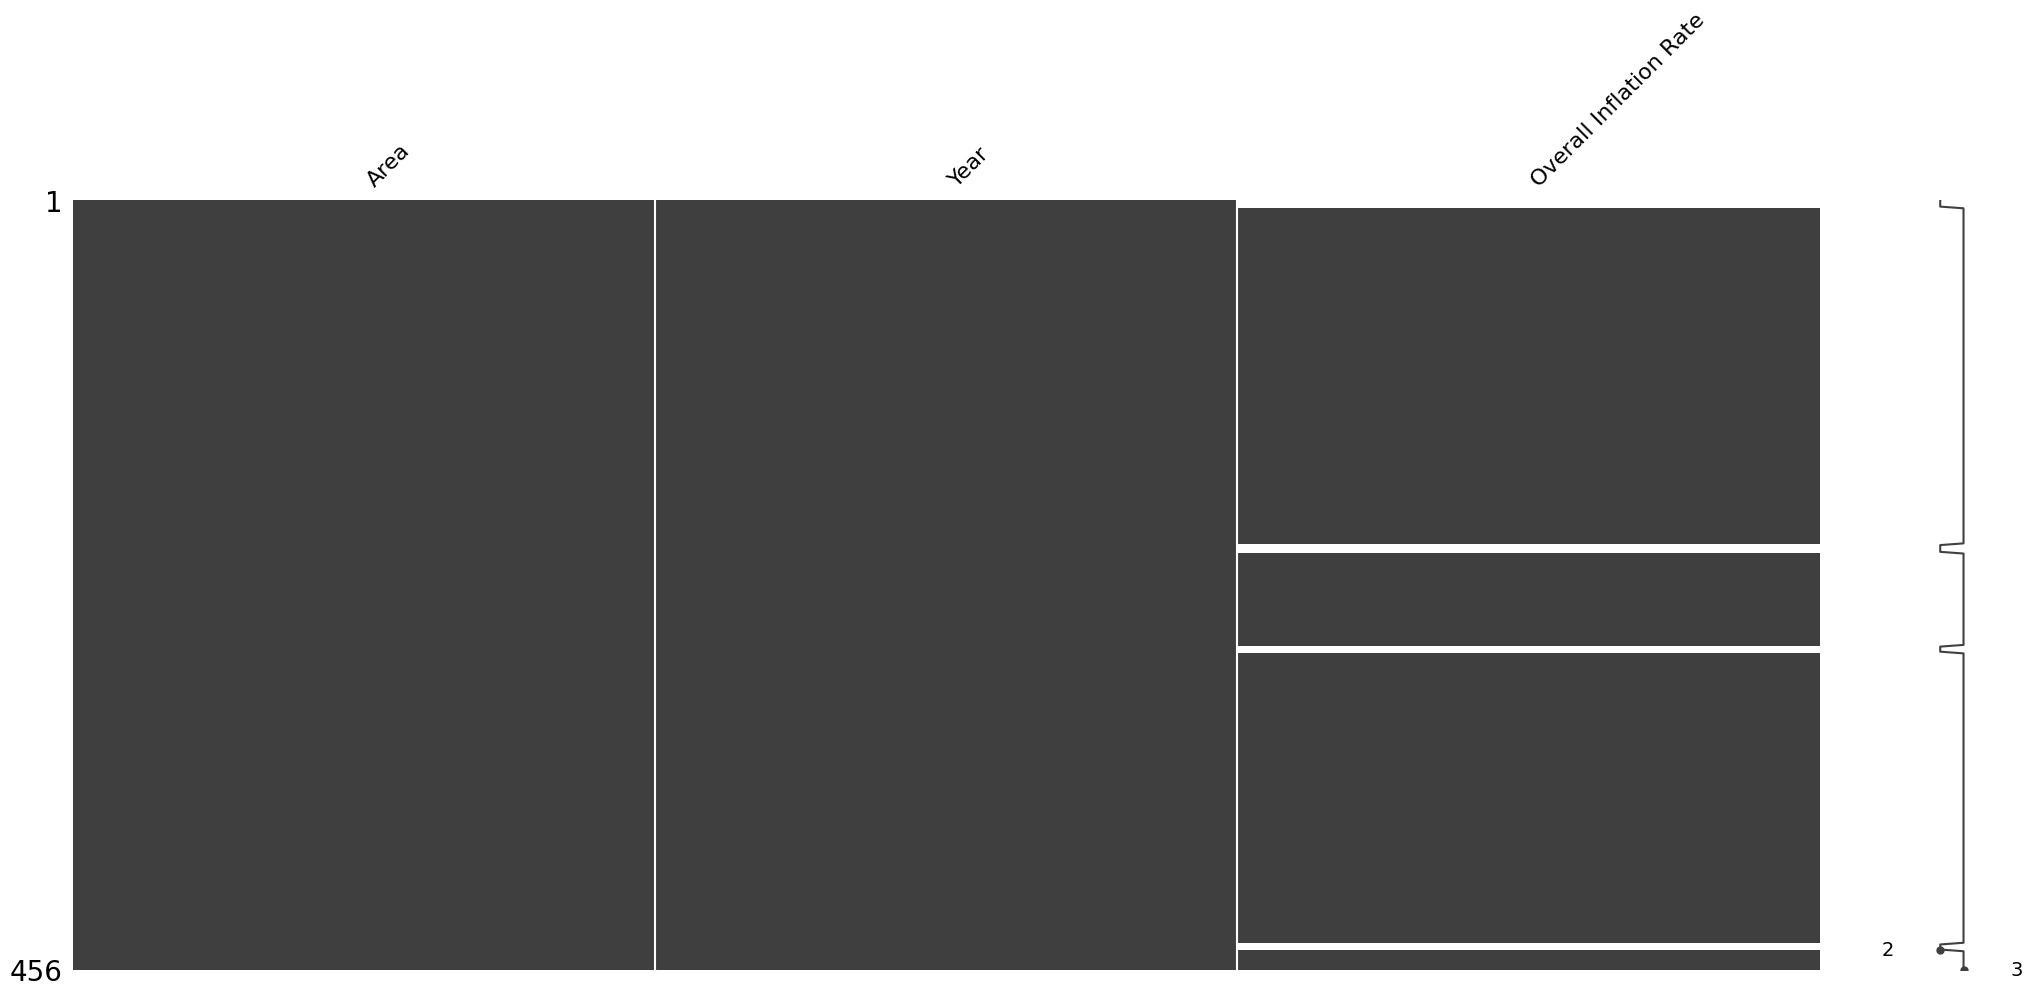

In [1106]:
msno.matrix(df) 

In [1107]:
tmp = dataset_overall_inflation.groupby('Area')['Overall Inflation Rate'].apply(lambda group: group.bfill()).reset_index()

In [1108]:
tmp = tmp.rename(columns={'level_1': 'index'})

In [1109]:
tmp = tmp.set_index('index')

In [1110]:
dataset_overall_inflation['Overall Inflation Rate'] = tmp['Overall Inflation Rate']

In [1111]:
tmp = dataset_overall_inflation.groupby('Area')['Overall Inflation Rate'].apply(lambda group: group.ffill()).reset_index()

In [1112]:
tmp = tmp.rename(columns={'level_1': 'index'})

In [1113]:
tmp = tmp.set_index('index')

In [1114]:
dataset_overall_inflation['Overall Inflation Rate'] = tmp['Overall Inflation Rate']

In [1115]:
dataset_overall_inflation

,Area,Year,Overall Inflation Rate
34,Albania,2012,3.2
73,Albania,2013,3.2
112,Albania,2014,3.2
151,Albania,2015,3.2
190,Albania,2016,3.2
...,...,...,...
311,United States,2019,1.4
350,United States,2020,0.8
389,United States,2021,5.3
428,United States,2022,8.7


In [1116]:
data = pd.merge(dataset_food_inflation_rate, dataset_raw_gdp, on=['Area', 'Year'], how='inner')

In [1117]:
data['Area'].unique()

array(['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'Montenegro',
       'Netherlands (Kingdom of the)', 'North Macedonia', 'Norway',
       'Poland', 'Portugal', 'Republic of Moldova', 'Romania',
       'Russian Federation', 'San Marino', 'Serbia', 'Slovakia',
       'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine',
       'United Kingdom of Great Britain and Northern Ireland'],
      dtype=object)

In [1118]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP
0,Albania,2012,2.404087,12319.779604
1,Albania,2013,4.214607,12776.280738
2,Albania,2014,2.212385,13228.240079
3,Albania,2015,4.294233,11386.924853
4,Albania,2016,3.254620,11861.356451


In [1119]:
data = pd.merge(data, dataset_gdp_growth_rate, on=['Area', 'Year'], how='inner')

In [1120]:
data['Area'].unique()

array(['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'Montenegro',
       'Netherlands (Kingdom of the)', 'North Macedonia', 'Norway',
       'Poland', 'Portugal', 'Republic of Moldova', 'Romania',
       'Russian Federation', 'San Marino', 'Serbia', 'Slovakia',
       'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine',
       'United Kingdom of Great Britain and Northern Ireland'],
      dtype=object)

In [1121]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate
0,Albania,2012,2.404087,12319.779604,-4.430218
1,Albania,2013,4.214607,12776.280738,3.705432
2,Albania,2014,2.212385,13228.240079,3.537487
3,Albania,2015,4.294233,11386.924853,-13.919579
4,Albania,2016,3.254620,11861.356451,4.166459


In [1122]:
data = pd.merge(data, dataset_producer_prices, on=['Area', 'Year'], how='inner')

In [1123]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'Netherlands (Kingdom of the)',
       'North Macedonia', 'Norway', 'Poland', 'Portugal',
       'Republic of Moldova', 'Romania', 'Russian Federation', 'Serbia',
       'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland',
       'Ukraine', 'United Kingdom of Great Britain and Northern Ireland'],
      dtype=object)

In [1124]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.1
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4


In [1125]:
dataset_overall_inflation['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany',
       'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo*',
       'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro',
       'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal',
       'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland', 'Türkiye', 'United Kingdom', 'United States'],
      dtype=object)

In [1126]:
data = pd.merge(data, dataset_overall_inflation, on=['Area', 'Year'], how='inner')

In [1127]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland'], dtype=object)

In [1128]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.1,3.2
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2


In [1129]:
annual_growth = pd.read_csv('./data/import_export_annual_growth_data.csv')
annual_growth.columns = annual_growth.columns.str.replace(r"\s*\[YR\d{4}\]", "", regex=True)
annual_growth = annual_growth.drop(columns=["Country Code", "Series Code"])
annual_growth.rename(columns={'Country Name': 'Area'}, inplace=True)

In [1130]:
annual_growth['Area'].unique()

array(['Turkiye', 'Albania', 'Austria', 'Bulgaria', 'Croatia',
       'Euro area', 'Estonia', 'France', 'Germany', 'Greece', 'Slovenia',
       'Slovakia', 'Spain', 'Sweden', 'United Kingdom', 'Belgium',
       'Czechia', 'Denmark', 'Finland', 'Hungary', 'Iceland', 'Ireland',
       'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
       'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania',
       'Serbia', 'Switzerland'], dtype=object)

In [1131]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland'], dtype=object)

In [1132]:
annual_growth_import = annual_growth[annual_growth['Series Name'] == 'Imports of goods and services (annual % growth)'].drop(columns=["Series Name"])

annual_growth_export = annual_growth[annual_growth['Series Name'] == 'Exports of goods and services (annual % growth)'].drop(columns=["Series Name"])

In [1133]:
annual_growth_import = annual_growth_import.melt(id_vars=['Area'], var_name='Year', value_name='Import Rate')

annual_growth_export = annual_growth_export.melt(id_vars=['Area'], var_name='Year', value_name='Export Rate')

In [1134]:
annual_growth_import['Year'] = annual_growth_import['Year'].astype(int)

annual_growth_export['Year'] = annual_growth_export['Year'].astype(int)

In [1135]:
data = pd.merge(data, annual_growth_import, on=['Area', 'Year'], how='inner')

data = pd.merge(data, annual_growth_export, on=['Area', 'Year'], how='inner')

In [1136]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland'], dtype=object)

In [1137]:
unemployment_rate = pd.read_csv('./data/unemployment_rate_data.csv')
unemployment_rate.rename(columns={'Country Name': 'Area'}, inplace=True)

In [1138]:
unemployment_rate = unemployment_rate.melt(id_vars=['Area'], var_name='Year', value_name='Unemployment Rate')

In [1139]:
unemployment_rate['Year'] = unemployment_rate['Year'].astype(int)

In [1140]:
unemployment_rate.head()

,Area,Year,Unemployment Rate
0,Albania,2012,13.376
1,Austria,2012,4.909
2,Belgium,2012,7.542
3,Bulgaria,2012,12.270
4,Croatia,2012,15.935


In [1141]:
data = pd.merge(data, unemployment_rate, on=['Area', 'Year'], how='inner')

In [1142]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland'], dtype=object)

In [1143]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.1,3.2,-6.930669,0.293588,13.376
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376


In [1144]:
official_exchange_rate = pd.read_csv('./data/official_exchange_rate_(local_currency_per_us_dollar).csv', delimiter=',')
official_exchange_rate.rename(columns={'Country Name': 'Area'}, inplace=True)

In [1145]:
official_exchange_rate = official_exchange_rate.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'])

In [1146]:
official_exchange_rate.head()

,Area,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.790000,1.790000,1.790000,1.790000,1.790000,1.790000,1.790000,1.790000,1.79000,NaN
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1.719656e+01,1.719656e+01,1.719656e+01,3.510964e+01,3.869226e+01,3.869226e+01,3.869226e+01,3.869226e+01,3.869226e+01,...,67.866086,68.026904,72.083247,77.737949,76.813536,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,2.866844e-08,2.873486e-08,2.867844e-08,2.875203e-08,2.881978e-08,2.877853e-08,2.882386e-08,2.884161e-08,2.872761e-08,...,163.656434,165.915951,252.855748,364.825805,578.258780,631.441956,460.567512,685.020238,869.84619,NaN


In [1147]:
official_exchange_rate = official_exchange_rate.melt(id_vars=['Area'], var_name='Year', value_name='Official Exchange Rate')

In [1148]:
official_exchange_rate['Year_numeric'] = pd.to_numeric(official_exchange_rate['Year'], errors='coerce')
official_exchange_rate = official_exchange_rate[official_exchange_rate['Year_numeric'].notna()]
official_exchange_rate['Year'] = official_exchange_rate['Year_numeric'].astype(int)
official_exchange_rate = official_exchange_rate.drop(columns='Year_numeric')

In [1149]:
official_exchange_rate.head()

,Area,Year,Official Exchange Rate
0,Aruba,1960,NaN
1,Africa Eastern and Southern,1960,NaN
2,Afghanistan,1960,1.719656e+01
3,Africa Western and Central,1960,NaN
4,Angola,1960,2.866844e-08


In [1150]:
data = pd.merge(data, official_exchange_rate, on=['Area', 'Year'], how='inner')

In [1151]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland'], dtype=object)

In [1152]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate,Official Exchange Rate
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376,108.184167
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376,108.184167
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376,108.184167
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.1,3.2,-6.930669,0.293588,13.376,108.184167
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376,108.184167


In [1153]:
data['Area'] = data['Area'].replace('North Macedonia', 'Macedonia')

In [1154]:
data.isnull().sum()

Area                      0
Year                      0
Food Inflation Rate       0
Raw GDP                   0
GDP Growth Rate           0
Item                      0
Item Price Per Tonne      0
Overall Inflation Rate    0
Import Rate               0
Export Rate               0
Unemployment Rate         0
Official Exchange Rate    0
dtype: int64

In [1155]:
data['Area'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia', 'Lithuania',
       'Luxembourg', 'Malta', 'Macedonia', 'Norway', 'Poland', 'Portugal',
       'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland'], dtype=object)

In [1156]:
data['Difference of inflation'] = data['Food Inflation Rate'] - data['Overall Inflation Rate']

In [1157]:
mean_value = data['Difference of inflation'].mean()
std_dev = data['Difference of inflation'].std()
mean_value, std_dev

(np.float64(1.0527960098507028), np.float64(2.337104827231194))

In [1158]:
alpha = 0.05

data['z_score'] = (data['Difference of inflation'] - mean_value) / std_dev
z_critical = norm.ppf(1 - alpha)

data['label'] = (data['z_score'] > z_critical).astype(int)

In [1159]:
z_critical

np.float64(1.644853626951472)

In [1160]:
len(data[data['label'] == 0]), len(data[data['label'] == 1])

(15855, 1225)

In [1161]:
data.head()

,Area,Year,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate,Official Exchange Rate,Difference of inflation,z_score,label
0,Albania,2012,2.404087,12319.779604,-4.430218,Apples,369.7,3.2,-6.930669,0.293588,13.376,108.184167,-0.795913,-0.791025,0
1,Albania,2012,2.404087,12319.779604,-4.430218,Apricots,489.9,3.2,-6.930669,0.293588,13.376,108.184167,-0.795913,-0.791025,0
2,Albania,2012,2.404087,12319.779604,-4.430218,Barley,316.1,3.2,-6.930669,0.293588,13.376,108.184167,-0.795913,-0.791025,0
3,Albania,2012,2.404087,12319.779604,-4.430218,"Beans, dry",1562.1,3.2,-6.930669,0.293588,13.376,108.184167,-0.795913,-0.791025,0
4,Albania,2012,2.404087,12319.779604,-4.430218,Cabbages,203.4,3.2,-6.930669,0.293588,13.376,108.184167,-0.795913,-0.791025,0


In [1162]:
threshold = mean_value + std_dev

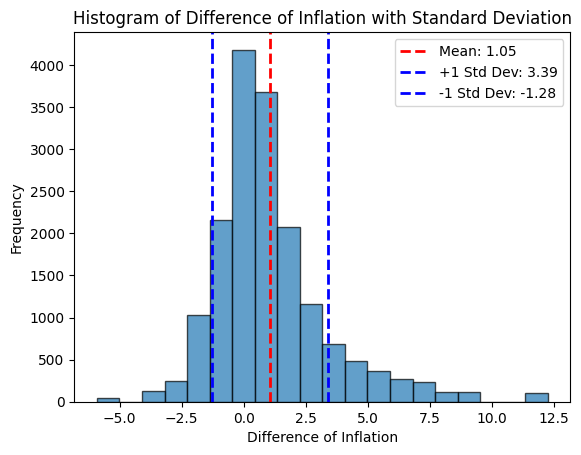

In [1163]:
plt.hist(data['Difference of inflation'], bins=20, edgecolor='black', alpha=0.7)

plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value:.2f}')
plt.axvline(mean_value + std_dev, color='blue', linestyle='dashed', linewidth=2,
            label=f'+1 Std Dev: {mean_value + std_dev:.2f}')
plt.axvline(mean_value - std_dev, color='blue', linestyle='dashed', linewidth=2,
            label=f'-1 Std Dev: {mean_value - std_dev:.2f}')

plt.title('Histogram of Difference of Inflation with Standard Deviation')
plt.xlabel('Difference of Inflation')
plt.ylabel('Frequency')

plt.legend()

plt.show()

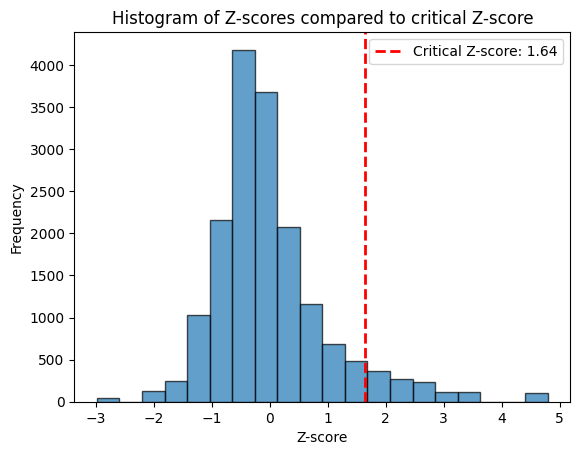

In [1164]:
plt.hist(data['z_score'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(z_critical, color='red', linestyle='dashed', linewidth=2,
            label=f'Critical Z-score: {z_critical:.2f}')

plt.title('Histogram of Z-scores compared to critical Z-score')
plt.xlabel('Z-score')
plt.ylabel('Frequency')

plt.legend()

plt.show()

In [1165]:
data.drop(columns=['Difference of inflation', 'z_score'], inplace=True)

In [1166]:
data.to_csv('./data/data.csv', index=False)